# Czynniki wpływajace na srednia ocene studentow

## Cel
Celem projektu jest zbadanie czynników wpływających na średnią ocenę studentów. W tym celu zostaną przeprowadzone analizy statystyczne oraz zastosowane różne modele uczenia maszynowego, aby określić, które czynniki mają największy wpływ na wyniki studentów.

## Hipotezy badawcze
1. Czy wiek studenta ma wpływ na jego średnią ocenę?
2. Czy czas poświecony na naukę tygodniowo ma wpływ na średnią ocenę?
3. Czy Nieobecności mają wpływ na średnią ocenę?
4. Czy wsparcie rodziców wpływa na średnią ocenę?
5. Czy inne aktywnosci poza szkolne wływaja na srednia ocene?

# Import niezbędnych bibliotek


In [302]:
# potrzebne
import math
import pandas as pd
import numpy as np

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

# modele
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# metryki
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score

# wizualizacja
import matplotlib.pyplot as plt
import seaborn as sns

#redukcja wymiarowości
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


# Eksploracja danych

In [303]:
data = pd.read_csv('data/Student_performance_data.csv', index_col='IDStudenta', names=["IDStudenta", "Wiek", "Plec", "Pochodzenie", "WyksztalcenieRodzica", "CzasSpedzonyNaNauceTyg.", "Nieobecnosci", "Tutoring", "WsparcieRodzicow", "ZajeciaPozalekcyjne", "Sport", "Muzyka", "Wolontariat", "SredniaKoncowa"], header=0)


print("Mamy", data.shape[0], "wierszy i", data.shape[1], "kolumn")
data.head()


Mamy 2392 wierszy i 13 kolumn


,Wiek,Plec,Pochodzenie,WyksztalcenieRodzica,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,WsparcieRodzicow,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
IDStudenta,,,,,,,,,,,,,
1001,21,Female,Caucasian,Some College,19.833723,7,Yes,Moderate,0,0,1,0,2.929196
1002,22,Male,Caucasian,High School,15.408756,0,No,Low,0,0,0,0,3.042915
1003,19,Male,Asian,Bachelor's,4.210570,26,No,Moderate,0,0,0,0,0.112602
1004,21,Female,Caucasian,Bachelor's,10.028829,14,No,High,1,0,0,0,2.054218
1005,21,Female,Caucasian,Some College,4.672495,17,Yes,High,0,0,0,0,1.288061


### Analiza statystyczna danych

In [304]:
data.describe() #można też zrobić data.describe(include='all') żeby wyświetlić wszystkie rodzaje danych, które wystepują w secie a nie tylko numeryczne

,Wiek,CzasSpedzonyNaNauceTyg.,Nieobecnosci,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
count,2392.000000,2389.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,20.468645,9.773029,14.541388,0.383361,0.303512,0.196906,0.157191,1.906186
std,1.123798,5.652477,8.467417,0.486307,0.459870,0.397744,0.364057,0.915156
min,19.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,5.043640,7.000000,0.000000,0.000000,0.000000,0.000000,1.174803
50%,20.000000,9.705614,15.000000,0.000000,0.000000,0.000000,0.000000,1.893393
75%,21.000000,14.408321,22.000000,1.000000,1.000000,0.000000,0.000000,2.622216
max,22.000000,19.978094,29.000000,1.000000,1.000000,1.000000,1.000000,4.000000


Wnioski:
- Widzimy ze wartosci sa w formacie tekstowym a powinny byc numeryczne aby modele lepiej dzialaly
- kolumna z 'srednia' nie jest zaokraglona


### Wizualizacja danych dotyczących średniej ocen końcowych studentów

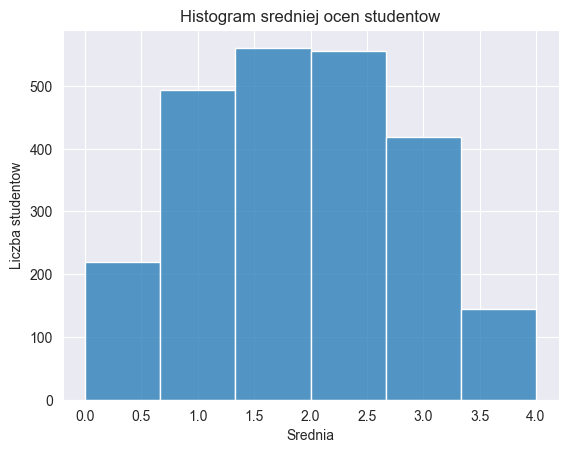

In [305]:
sns.histplot(data['SredniaKoncowa'], bins=6)
plt.xlabel('Srednia')
plt.ylabel('Liczba studentow')
plt.title('Histogram sredniej ocen studentow')
plt.show()

### Wizualizacja danych dotyczących pochodzenia studentów

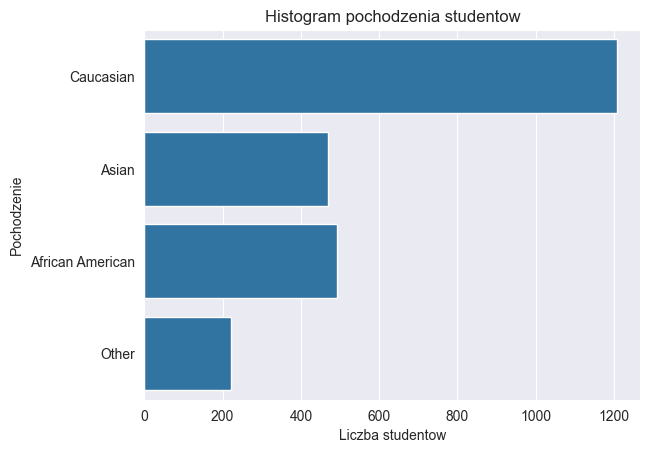

In [306]:
sns.countplot(data['Pochodzenie'])
plt.xlabel('Liczba studentow')
plt.ylabel('Pochodzenie')
plt.title('Histogram pochodzenia studentow')
plt.show()


### Wizualizacja danych dotyczących wykształcenia rodziców studentów

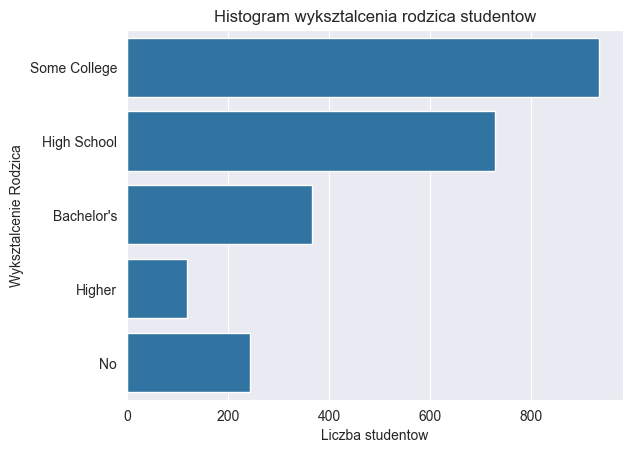

In [307]:
sns.countplot(data['WyksztalcenieRodzica'])
plt.xlabel('Liczba studentow')
plt.ylabel('Wyksztalcenie Rodzica')
plt.title('Histogram wyksztalcenia rodzica studentow')
plt.show()

### Wizualizacja danych dotyczących płci studentów

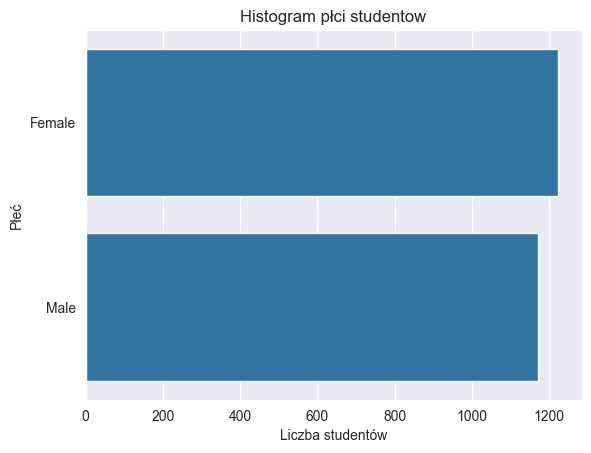

In [308]:
sns.countplot(data['Plec'])
plt.xlabel('Liczba studentów')
plt.ylabel('Płeć')
plt.title('Histogram płci studentow')
plt.show()

# 2. Preprocessing danych

## Uzupełnienie brakujących wartości
### - na podstawie średniej wartości tygodniowego czasu spędzonego na nauce

### Sprawdzenie czy występują brakujące wartości

In [309]:
print(data.isnull().sum()[data.isnull().sum() > 0])
print()

CzasSpedzonyNaNauceTyg.    3
dtype: int64



Możemy zauważyć, że w zbiorze danych wsytępują brakujące wartości, które należy uzupełnić.

### Uzupłenianie pustych wartości w kolumnie "CzasSpedzonyNaNauceTyg" na podstawie średniej wartości tej kolumny

In [310]:
data['CzasSpedzonyNaNauceTyg.'] = data['CzasSpedzonyNaNauceTyg.'].fillna(data['CzasSpedzonyNaNauceTyg.'].mean())

### Ponowne sprawdzenie czy pozbyliśmy się pustych wartości

In [311]:
print(data.isnull().sum()[data.isnull().sum() > 0])

Series([], dtype: int64)


## Zamiana wartosci kategorycznych(tekstowych) na numeryczne, aby algorytmy mogły je zrozumieć

In [312]:
labelEncoder = LabelEncoder()
data['Plec'] = labelEncoder.fit_transform(data['Plec']) # Female -> 0 Male -> 1
data['Tutoring'] = labelEncoder.fit_transform(data['Tutoring']) # No -> 0 Yes -> 1

data.head()

,Wiek,Plec,Pochodzenie,WyksztalcenieRodzica,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,WsparcieRodzicow,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
IDStudenta,,,,,,,,,,,,,
1001,21,0,Caucasian,Some College,19.833723,7,1,Moderate,0,0,1,0,2.929196
1002,22,1,Caucasian,High School,15.408756,0,0,Low,0,0,0,0,3.042915
1003,19,1,Asian,Bachelor's,4.210570,26,0,Moderate,0,0,0,0,0.112602
1004,21,0,Caucasian,Bachelor's,10.028829,14,0,High,1,0,0,0,2.054218
1005,21,0,Caucasian,Some College,4.672495,17,1,High,0,0,0,0,1.288061


### 1. Zamiana za pomoca LabelEncoder
- niepoprawna dla więcej niź 2 kategorii, ponieważ tworzy się "sztuczna hierarchia"


In [313]:
# data['Pochodzenie'] = labelEncoder.fit_transform(data['Pochodzenie'])
# data['WyksztalcenieRodzica'] = labelEncoder.fit_transform(data['WyksztalcenieRodzica'])
# data['WsparcieRodzicow'] = labelEncoder.fit_transform(data['WsparcieRodzicow'])
# 
# data.head()

In [314]:
# corr = data.corr()
# sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f')
# plt.title('Macierz korelacji')
# plt.show()

### 2. Zamiana za pomoca OneHotEncoder
OneHotEncoder zamienia kategorie na osobne kolumny zer i jedynek

In [315]:
oneHotEncoder = OneHotEncoder(sparse_output=False, drop='first')
oneHotEncoder2 = OneHotEncoder(sparse_output=False, drop='first')
oneHotEncoder3 = OneHotEncoder(sparse_output=False, drop='first')

pochodzenieMatrix = oneHotEncoder.fit_transform(data[['Pochodzenie']])
wyksztalcenieMatrix = oneHotEncoder2.fit_transform(data[['WyksztalcenieRodzica']])
wsparcieRodzicowMatrix = oneHotEncoder3.fit_transform(data[['WsparcieRodzicow']])

pochodzenieDF = pd.DataFrame(pochodzenieMatrix, columns=oneHotEncoder.get_feature_names_out(['Pochodzenie']))
wyksztalcenieDF = pd.DataFrame(wyksztalcenieMatrix, columns=oneHotEncoder2.get_feature_names_out(['WyksztalcenieRodzica']))
wsparcieRodzicowDF = pd.DataFrame(wsparcieRodzicowMatrix, columns=oneHotEncoder3.get_feature_names_out(['WsparcieRodzicow']))

pochodzenieDF.index = data.index
wyksztalcenieDF.index = data.index
wsparcieRodzicowDF.index = data.index

data = pd.concat([data, pochodzenieDF, wyksztalcenieDF, wsparcieRodzicowDF], axis=1)
data.drop(columns=['Pochodzenie', 'WyksztalcenieRodzica', 'WsparcieRodzicow'], inplace=True)

data.head()

,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa,...,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,,
1001,21,0,19.833723,7,1,0,0,1,0,2.929196,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1002,22,1,15.408756,0,0,0,0,0,0,3.042915,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1003,19,1,4.210570,26,0,0,0,0,0,0.112602,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1004,21,0,10.028829,14,0,1,0,0,0,2.054218,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1005,21,0,4.672495,17,1,0,0,0,0,1.288061,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


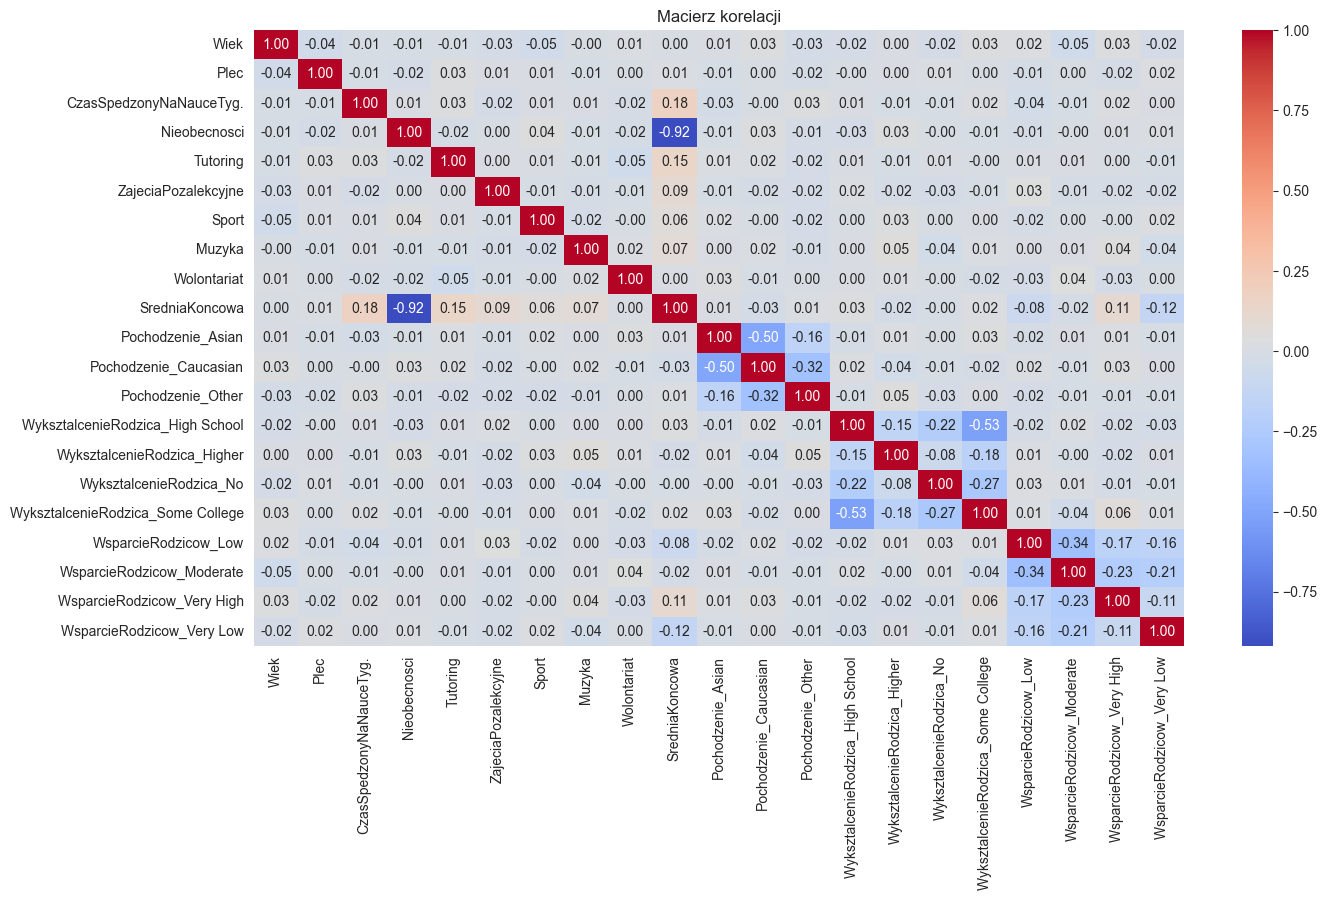

In [316]:
plt.figure(figsize=(15, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji')
plt.show()

## Wizualizacja (sprawdzić czy ok czy inaczej to robić)

## Redukcja wymiarowości (opisać)

#### Standaryzacja


In [ ]:
#Potrzebna do PCA
X = data.drop(columns=['SredniaKoncowa'])
y = data['SredniaKoncowa']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### PCA (opisać)

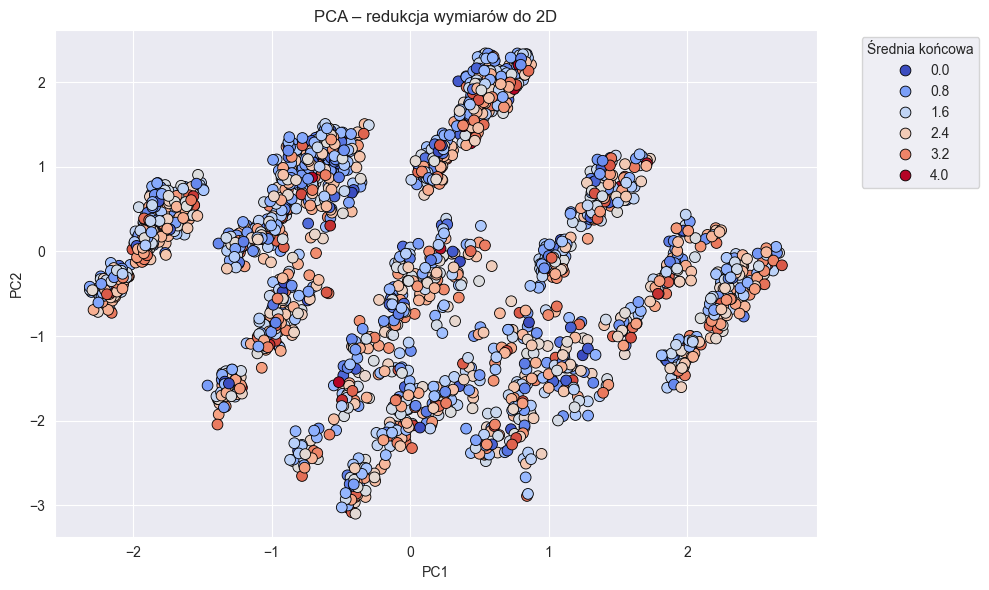

In [318]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='coolwarm', s=60, edgecolor='k')
plt.title('PCA – redukcja wymiarów do 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Średnia końcowa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [319]:
# Dopasowanie PCA do danych
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Wydobycie wag (ładunków) cech dla dwóch pierwszych składowych
loadings = pd.DataFrame(pca.components_.T, 
                        columns=['PC1', 'PC2'], 
                        index=data.drop(columns=['SredniaKoncowa']).columns)

# Sortowanie cech według wpływu na PC1
print("Najbardziej wpływające cechy na PC1:")
print(loadings['PC1'].sort_values(ascending=False).head(5))
print("\nNajbardziej wpływające cechy na PC2:")
print(loadings['PC2'].sort_values(ascending=False).head(5))


Najbardziej wpływające cechy na PC1:
WyksztalcenieRodzica_Some College    0.570410
Pochodzenie_Asian                    0.368515
Pochodzenie_Other                    0.156317
WsparcieRodzicow_Very High           0.093084
WsparcieRodzicow_Very Low            0.056322
Name: PC1, dtype: float64

Najbardziej wpływające cechy na PC2:
Pochodzenie_Caucasian                0.577201
WyksztalcenieRodzica_Some College    0.387304
WsparcieRodzicow_Low                 0.164535
WsparcieRodzicow_Very High           0.140883
Wiek                                 0.104446
Name: PC2, dtype: float64


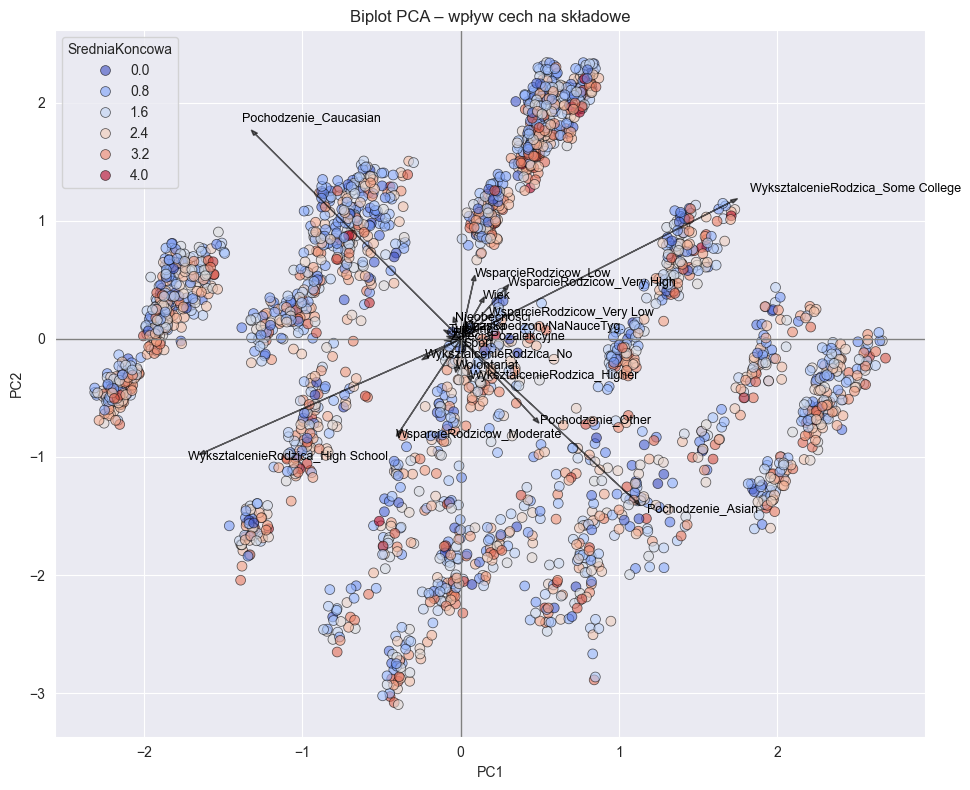

In [321]:
plt.figure(figsize=(10, 8))

# Punkty (studenci)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='coolwarm', s=50, alpha=0.6, edgecolor='k')

# Strzałki (cechy) 
#  - Długość strzałki - siła wpływu cechy.
#  - Kierunek strzałki - jak cecha koreluje z PC1 i PC2.
#  - Jeśli dwie strzałki są blisko siebie - te cechy są ze sobą skorelowane.
#  - Jeśli strzałka jest daleko od środka - ta cecha mocno wpływa na któryś z komponentów.
for i, feature in enumerate(loadings.index):
    plt.arrow(0, 0, 
              loadings['PC1'].iloc[i]*3, loadings['PC2'].iloc[i]*3,
              color='black', alpha=0.6, head_width=0.03)
    plt.text(loadings['PC1'].iloc[i]*3.2, loadings['PC2'].iloc[i]*3.2, 
             feature, fontsize=9, color='black')

plt.title('Biplot PCA – wpływ cech na składowe')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.tight_layout()
plt.show()


### t-SNE (opisać)

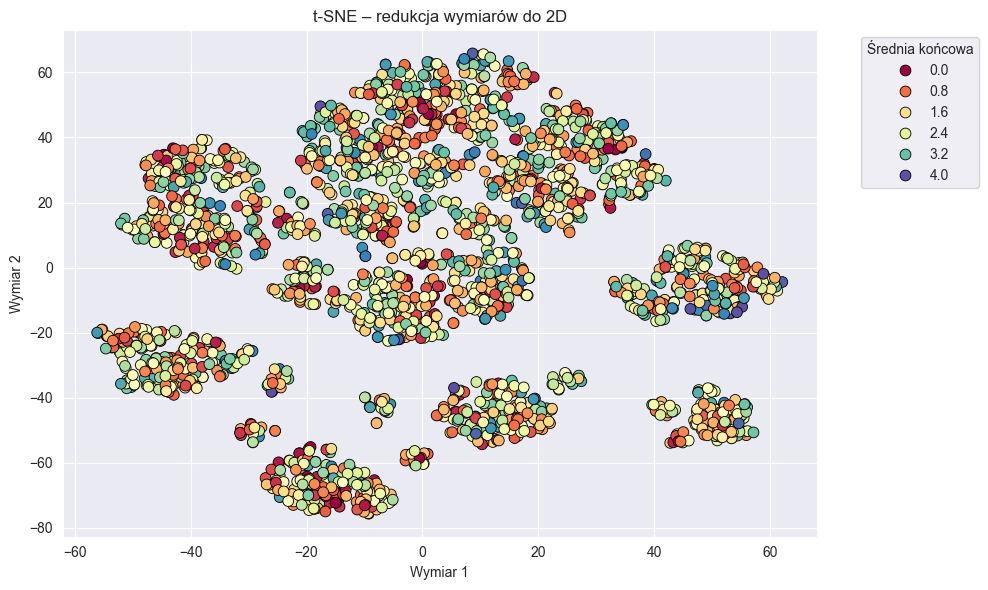

In [322]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette='Spectral', s=60, edgecolor='k')
plt.title('t-SNE – redukcja wymiarów do 2D')
plt.xlabel('Wymiar 1')
plt.ylabel('Wymiar 2')
plt.legend(title='Średnia końcowa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### OPCJONALNIE - można zrobić jeszcze wykresy względem poszczególnych cech ale nie wiem czy jest sens

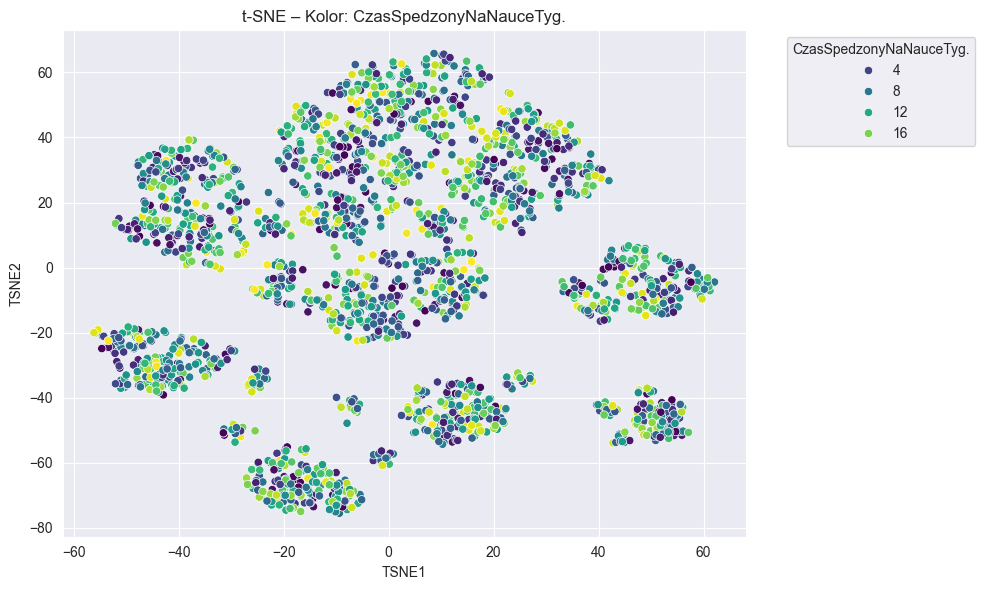

In [342]:
# Mapowanie jednej cechy np. CzasSpedzonyNaNauceTyg. na kolor t-SNE
feature_to_plot = 'CzasSpedzonyNaNauceTyg.'
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=data[feature_to_plot], palette='viridis')
plt.title(f't-SNE – Kolor: {feature_to_plot}')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.legend(title=feature_to_plot, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [324]:
# data['SredniaKoncowa_kategorie'] = pd.cut(data['SredniaKoncowa'], bins=5)
# 
# plt.figure(figsize=(15, 8))
# sns.pairplot(data[['Plec','CzasSpedzonyNaNauceTyg.','Nieobecnosci','SredniaKoncowa_kategorie']],
#              diag_kind='kde',
#              hue='SredniaKoncowa_kategorie',
#              kind='reg',
#              plot_kws={'line_kws': {'color': 'red'}})
# plt.title('Wizualizacja danych')
# plt.show()
# data=data.drop(columns=['SredniaKoncowa_kategorie'], axis=1)

# 3. Wybór modeli

## Zmienne ciągłe w kolumnie SredniaKoncowa


### Podzial na zbior testowy i treningowy

In [325]:
X = data.drop(columns=['SredniaKoncowa'], axis=1)
y = data['SredniaKoncowa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Treningowy zbior:",X_train.shape)
print("Testowy zbior:",X_test.shape)

print("\nZbiór treningowy: ")
X_test.head()

Treningowy zbior: (1913, 20)
Testowy zbior: (479, 20)

Zbiór treningowy: 


,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,Pochodzenie_Asian,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,
2005,19,0,0.135763,17,0,0,1,1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1197,20,0,1.989925,0,0,1,0,0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3343,19,1,10.588715,15,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2709,22,0,16.208658,1,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1436,22,1,3.576821,27,0,0,1,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


### Regresja liniowa
Regresja liniowa znajduje najlepiej pasującą prostą do punktów na wykresie, pokazując jak jedna rzecz wpływa na drugą. Dzięki niej można przewidywać wyniki (np. ile zarobisz, pracując więcej godzin) lub sprawdzać zależności między danymi.

In [326]:
regresjaLiniowa = LinearRegression()
regresjaLiniowa.fit(X_train, y_train)

y_pred = regresjaLiniowa.predict(X_test)

r2= r2_score(y_test, y_pred)
print(f"R2: {r2:.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

R2: 0.9534
MAE: 0.1551


R2 - pokazuje, jak dobrze model pasuje do danych – im bliżej 100%, tym więcej zmienności danych tłumaczy.

MAE(Mean Absolute Error / Średni Błąd Bezwzględny) - średnia różnica między przewidywaniami a rzeczywistymi wartościami 

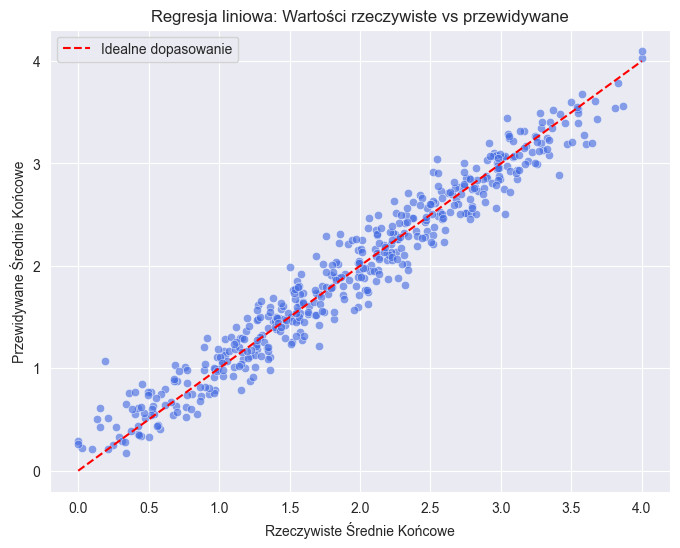

In [327]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='royalblue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Idealne dopasowanie')

plt.title('Regresja liniowa: Wartości rzeczywiste vs przewidywane')
plt.xlabel('Rzeczywiste Średnie Końcowe')
plt.ylabel('Przewidywane Średnie Końcowe')
plt.legend()
plt.grid(True)
plt.show()


## Klasyfikacja po skategoryzowaniu średnich

### Wykonujemy **dyskretyzację**, aby później przeprowadzić klasyfikację
Przekształcamy ciągłe wartości "SredniaKoncowa" na kategorie klasowe (A, B, C...) - przygotowujemy dane do klasyfikacji(czyli **przewidywania klas**, nie wartości liczbowych)


In [328]:
def licz_ocene(srednia):
    if srednia >= 3.5:
        return 4  # A
    elif srednia >= 3.0:
        return 3  # B
    elif srednia >= 2.5:
        return 2  # C
    elif srednia >= 2.0:
        return 1  # D
    else:
        return 0  # F

data['Ocena'] = data['SredniaKoncowa'].apply(licz_ocene)
data[['SredniaKoncowa', 'Ocena']].head()


,SredniaKoncowa,Ocena
IDStudenta,,
1001,2.929196,2
1002,3.042915,3
1003,0.112602,0
1004,2.054218,1
1005,1.288061,0


### Podzial na zbior testowy i treningowy

In [329]:
X = data.drop(columns=['SredniaKoncowa', 'Ocena'])
y = data['Ocena']

#proporcje 20(testowy)/80(treningowy) z ziarnem losowości 42 i stratyfikacją
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Treningowy zbior:",X_train.shape)
print("Testowy zbior:",X_test.shape)

print()
X_train.head()

Treningowy zbior: (1913, 20)
Testowy zbior: (479, 20)



,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,Pochodzenie_Asian,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,
1942,19,0,4.843669,21,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3163,21,1,6.212019,14,0,1,1,1,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2743,20,1,8.875672,25,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2408,19,1,4.430543,20,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1780,21,1,10.596181,22,0,1,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Standaryzacja
Standaryzacja to proces przekształcania danych, aby miały średnią 0 i odchylenie standardowe 1. Stosuje się ją, ponieważ wiele modeli jest wrażliwych na różne skale cech, a dzięki niej wszystkie cechy są równo traktowane.


In [330]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Zbior po standaryzacji")
print(np.mean(X_train, axis=0))
print(np.std(X_train, axis=0))

Zbior po standaryzacji
[ 7.60499870e-16  6.49999889e-17  3.08285662e-16  2.50714243e-17
 -4.45714210e-17  6.31428464e-17  7.05714165e-17 -3.62142795e-17
 -6.12857038e-17 -7.42857016e-18 -5.19999911e-17 -2.59999956e-17
  1.85714254e-17  1.07714267e-16 -4.36428497e-17 -9.09999845e-17
 -5.57142762e-18  5.57142762e-18 -5.19999911e-17  2.22857105e-17]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Wyrownywanie wartosci Y

In [331]:
print(y_train.value_counts())

Ocena
0    1019
1     329
2     308
3     195
4      62
Name: count, dtype: int64


### Analiza rozkładu klas
Pokazuje czy dane są zbalansowane. Niezbalansowane dane = gorsza jakość klasyfikacji

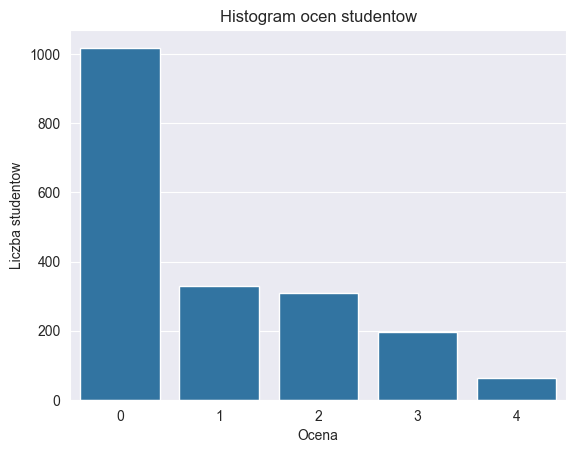

In [332]:
sns.countplot(x=y_train)
plt.xlabel('Ocena')
plt.ylabel('Liczba studentow')
plt.title('Histogram ocen studentow')
plt.show()

Możemy zauwazyć bardzo dużą przewagę klasy '0', co wskazuje na niezbalansowanie danych. 

#### 1. Udersampling
Zmniejszamy liczbę przykładów z klasy dominującej, aby zrównoważyć zbiór danych. Undersampling stosujemy w przypdaku dużej nierówności klas, aby uniknąc sytuacji w której model może nauczyć się przewidywać tylko jedną klasę

In [333]:
# underSampler = RandomUnderSampler()
#
# X_train, y_train = underSampler.fit_resample(X_train, y_train)
#
# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()
#
# print("Zbalansowany zbior")
# print(y_train.value_counts())


#### 2. Oversampling
Dodajemy więcej przykładów klasy mniejszościowej, np. przez kopiowanie lub generowanie sztucznych danych (np. SMOTE), żeby mieć równą liczbę przykładów w klasach, przez co model uczy się lepiej rozróżniać poszczególne klasy

In [334]:
# oversampler = SMOTE()
#
# X_train, y_train = oversampler.fit_resample(X_train, y_train)
#
# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()
#
# print("Zbalansowany zbior")
# print(y_train.value_counts())

#### 3. Undersampling + Oversampling

In [335]:
# underSampler = RandomUnderSampler(sampling_strategy='majority',random_state=42)
# oversampler = SMOTE(sampling_strategy='auto', random_state=42)
#
# X_train, y_train = underSampler.fit_resample(X_train, y_train)
# X_train, y_train = oversampler.fit_resample(X_train, y_train)
# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()
# print("Zbalansowany zbior")
# print(y_train.value_counts())


### Regresja Logistyczna
Model regresji logistycznej uczy się klasyfikacji, dzieląc dane krzywą 'S' na 5 przedziałów.


Dokładność: 0.8225469728601252


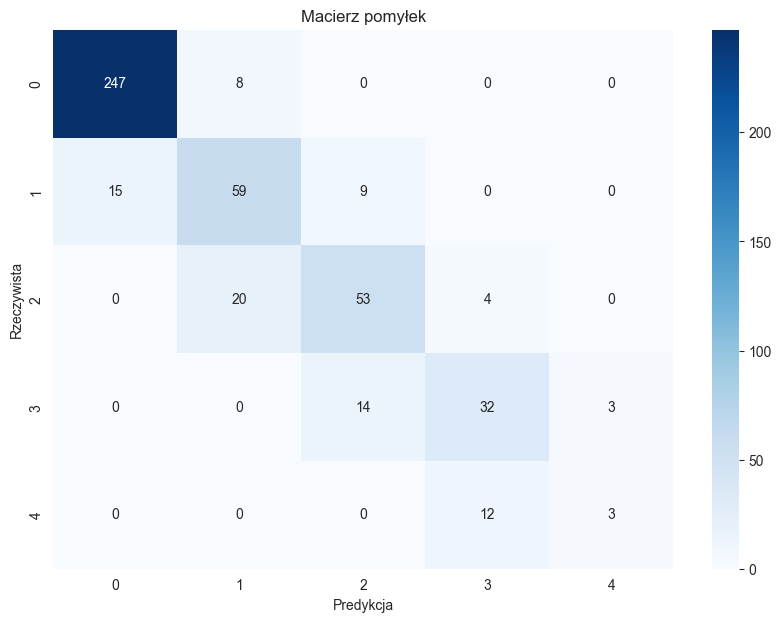

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       255
           1       0.68      0.71      0.69        83
           2       0.70      0.69      0.69        77
           3       0.67      0.65      0.66        49
           4       0.50      0.20      0.29        15

    accuracy                           0.82       479
   macro avg       0.70      0.64      0.66       479
weighted avg       0.82      0.82      0.82       479



In [336]:
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

accuracyRL= accuracy_score(y_test, y_pred)
print("Dokładność:", accuracyRL)

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista')
plt.title('Macierz pomyłek')
plt.show()

print("Raport klasyfikacji:\n", classification_report(y_test, y_pred))

f1SRL=f1_score(y_test, y_pred, average='macro')

### KNN
KNN tworzy mape punktów i klasyfikuje nowe punkty danych, wybierając dominującą klasę spośród k najbliższych przykładów ze zbioru treningowego


Dokładność: 0.5824634655532359


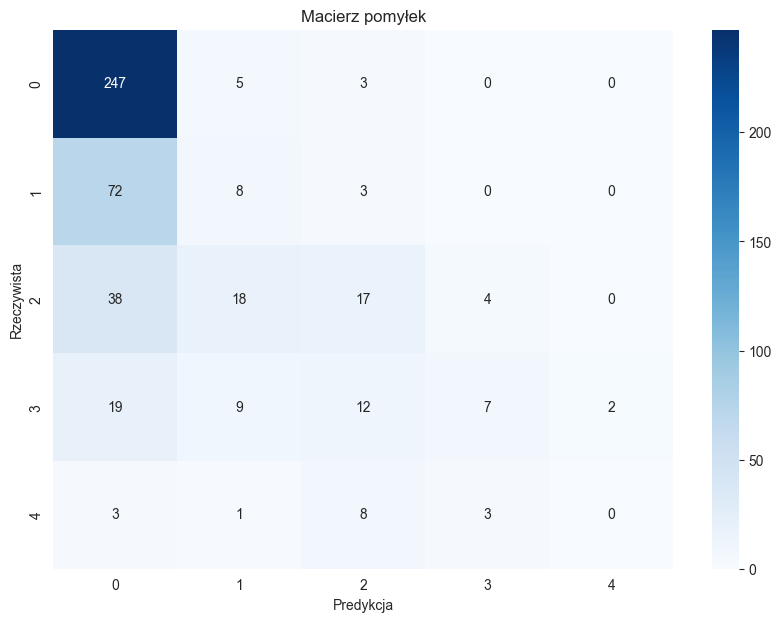

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.65      0.97      0.78       255
           1       0.20      0.10      0.13        83
           2       0.40      0.22      0.28        77
           3       0.50      0.14      0.22        49
           4       0.00      0.00      0.00        15

    accuracy                           0.58       479
   macro avg       0.35      0.29      0.28       479
weighted avg       0.50      0.58      0.51       479



In [337]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracyKNN = accuracy_score(y_test, y_pred)
print("Dokładność:", accuracyKNN)
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista')
plt.title('Macierz pomyłek')
plt.show()
print("Raport klasyfikacji:\n", classification_report(y_test, y_pred))

f1SKNN=f1_score(y_test, y_pred, average='macro')

### SVM
SVM rysuje granicę decyzyjną jak najdalej od punktów każdej klasy, a gdy są pomieszane, 'przepakowuje' dane w wyższą wymiarowość, gdzie da się je rozdzielić prosto.


Dokładność: 0.8413


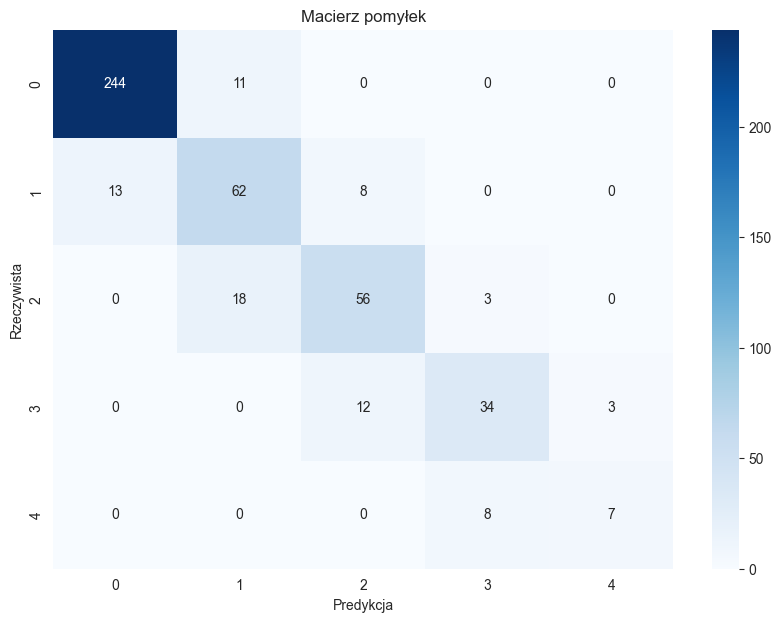

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95       255
           1       0.68      0.75      0.71        83
           2       0.74      0.73      0.73        77
           3       0.76      0.69      0.72        49
           4       0.70      0.47      0.56        15

    accuracy                           0.84       479
   macro avg       0.76      0.72      0.74       479
weighted avg       0.84      0.84      0.84       479



In [338]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

accuracySVM = accuracy_score(y_test, y_pred)
print(f"Dokładność: {accuracySVM:.4f}")
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista')
plt.title('Macierz pomyłek')
plt.show()
print("Raport klasyfikacji:\n", classification_report(y_test, y_pred))

f1SVM=f1_score(y_test, y_pred, average='macro')

### Porównanie efektywności modeli

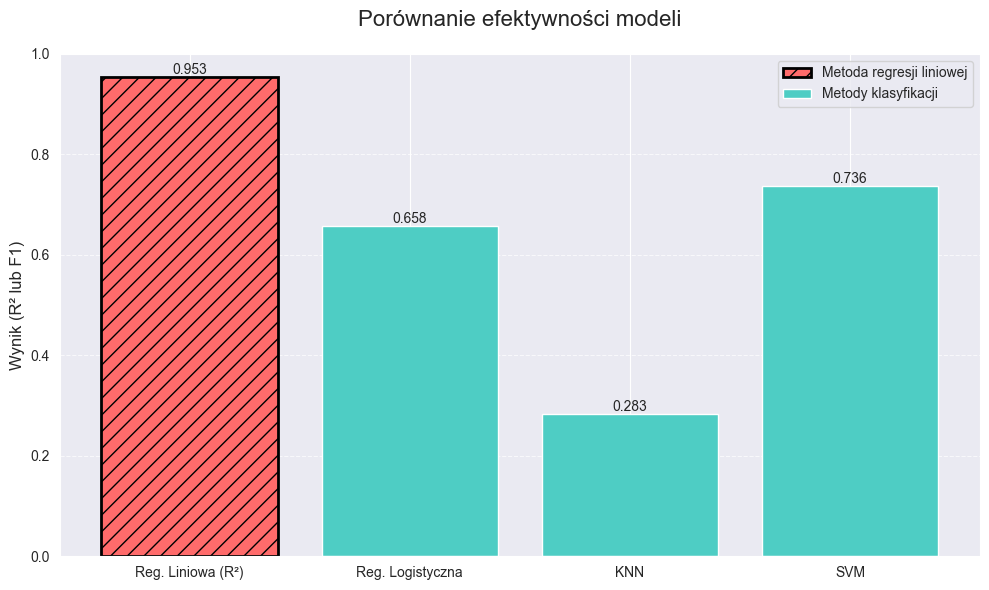

In [339]:
import matplotlib.pyplot as plt

models = ['Reg. Liniowa (R²)', 'Reg. Logistyczna', 'KNN', 'SVM']
scores = [r2, f1SRL, f1SKNN, f1SVM]

colors = ['#FF6B6B'] + ['#4ECDC4'] * (len(models)-1)  

plt.figure(figsize=(10, 6))
bars = plt.bar(models, scores, color=colors)

bars[0].set_edgecolor('black')  
bars[0].set_linewidth(2)        
bars[0].set_hatch('//')         

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')

plt.ylabel('Wynik (R² lub F1)', fontsize=12)
plt.title('Porównanie efektywności modeli', fontsize=16, pad=20)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend([bars[0], bars[1]], 
           ['Metoda regresji liniowej', 'Metody klasyfikacji'], 
           loc='upper right')

plt.tight_layout() 
plt.show()

# Podsumowanie wyników

In [340]:
print("==============================================")
print(" PODSUMOWANIE WYNIKÓW MODELI KLASYFIKACYJNYCH ")
print("==============================================")
print(f"1. Regresja Liniowa (R²): {r2:.4f}")
print(f"   • Interpretacja: Model wyjaśnia {r2*100:.1f}% wariancji danych")
print("   • R² ocenia dopasowanie modelu przewidującego wartości ciągłe, nie będąc miarą jakości klasyfikacji w której istotne są miary oparte na macierzy pomyłek.")
print("\n**********************************************\n")
print(f"2. Regresja Logistyczna (F1): {f1SRL:.4f}")
print(f"   • Jakość klasyfikacji: {'Dobra' if f1SRL > 0.7 else 'Średnia' if f1SRL > 0.5 else 'Niska'}")
print("   • Zalety: Szybki, interpretowalny")
print(f"   • Porównanie do KNN: {'lepszy' if f1SRL > f1SKNN else 'gorszy'} o {abs(f1SRL-f1SKNN):.3f}")
print(f"   • Porównanie do SVM: {'lepszy' if f1SRL > f1SVM else 'gorszy'} o {abs(f1SRL-f1SVM):.3f}")
print(f"   • Najlepszy model: {'TAK' if f1SRL == max([f1SRL, f1SKNN, f1SVM]) else 'NIE'}")
print("----------------------------------------------")
print(f"3. KNN (F1): {f1SKNN:.4f}")
print(f"   • Jakość klasyfikacji: {'Dobra' if f1SKNN > 0.7 else 'Średnia' if f1SKNN > 0.5 else 'Niska'}")
print(f"   • Porównanie do regresji: {'lepszy' if f1SKNN > f1SRL else 'gorszy'} o {abs(f1SKNN-f1SRL):.3f}")
print(f"   • Porównanie do SVM: {'lepszy' if f1SKNN > f1SVM else 'gorszy'} o {abs(f1SKNN-f1SVM):.3f}")
print(f"   • Najlepszy model: {'TAK' if f1SKNN == max([f1SRL, f1SKNN, f1SVM]) else 'NIE'}")
print("----------------------------------------------")
print(f"4. SVM (F1): {f1SVM:.4f}")
print(f"   • Jakość klasyfikacji: {'Dobra' if f1SVM > 0.7 else 'Średnia' if f1SVM > 0.5 else 'Niska'}")
print(f"   • Porównanie do regresji: {'lepszy' if f1SVM > f1SRL else 'gorszy'} o {abs(f1SVM-f1SRL):.3f}")
print(f"   • Porównanie do KNN: {'lepszy' if f1SVM > f1SKNN else 'gorszy'} o {abs(f1SVM-f1SKNN):.3f}")
print(f"   • Najlepszy model: {'TAK' if f1SVM == max([f1SRL, f1SKNN, f1SVM]) else 'NIE'}")
print("==============================================")
print(f"NAJLEPSZY WYNIK: {max([f1SRL, f1SKNN, f1SVM]):.4f} ({models[[f1SRL, f1SKNN, f1SVM].index(max([f1SRL, f1SKNN, f1SVM]))+1]})")
print("==============================================")

 PODSUMOWANIE WYNIKÓW MODELI KLASYFIKACYJNYCH 
1. Regresja Liniowa (R²): 0.9534
   • Interpretacja: Model wyjaśnia 95.3% wariancji danych
   • R² ocenia dopasowanie modelu przewidującego wartości ciągłe, nie będąc miarą jakości klasyfikacji w której istotne są miary oparte na macierzy pomyłek.

**********************************************

2. Regresja Logistyczna (F1): 0.6576
   • Jakość klasyfikacji: Średnia
   • Zalety: Szybki, interpretowalny
   • Porównanie do KNN: lepszy o 0.375
   • Porównanie do SVM: gorszy o 0.079
   • Najlepszy model: NIE
----------------------------------------------
3. KNN (F1): 0.2828
   • Jakość klasyfikacji: Niska
   • Porównanie do regresji: gorszy o 0.375
   • Porównanie do SVM: gorszy o 0.453
   • Najlepszy model: NIE
----------------------------------------------
4. SVM (F1): 0.7362
   • Jakość klasyfikacji: Dobra
   • Porównanie do regresji: lepszy o 0.079
   • Porównanie do KNN: lepszy o 0.453
   • Najlepszy model: TAK
NAJLEPSZY WYNIK: 0.7362 (SVM

In [341]:
# wybor najlepszego modelu

# print("Dokładnosc regresji liniowej:", round(r2,2))
# print("f1 regresji logistycznej:", round(f1SRL,2), "accuracy:", round(accuracyRL,2))
# print("f1 KNN:", round(f1SKNN,2), "accuracy:", round(accuracyKNN,2))
# print("f1 SVM:", round(f1SVM,2), "accuracy:", round(accuracySVM,2))


## Wnioski (Poprawic wnioski )
1. Na podstawie tych danych oraz tablicy korelacji możemu zauważyc ze Ważnym czynnikiem sa:
- nieobecnosci
- czas spedzony na nauce tygodniowo
- Tutoring
- wsparcie rodziców
Na wyniki nie wpływa:
- wiek
- plec
- pochodzenie
- wykształcenie rodziców
Oraz w mniejszym stopniu
- zajęcia pozalekcyjne
- sport
- muzyka
- wolontariat

2. Widzimy ze mamy bardzo niezbalansowane dane co nie dawało najlepsych wynikow. Najlepszym rozwiazaniem okazał się oversampling

3. Najlepszym modelem dla wartosci ciągłej jest regresja liniowa z wynikiem r2=0.95 a dla wartosci skategoryzowanych regresja logistyczna z wynikiem f1=0.7




# CO trzeba zrobic ?
- Stworzyc podpisy włumaczace wszytsko
- pomyslec czy nei mozna zrobic lepszej wizualizacji danych
- "3.Zastosowanie wybranego algorytmu do redukcji wymiarowości:Wizualizacja danych w przestrzeni 2D/3D + interpretacja." https://www.youtube.com/watch?v=FgakZw6K1QQ lub https://www.youtube.com/watch?v=TKnpSD1X_gY
- uzasadnic wyhor modelu ?
- zrobic lepsze porownanie